In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster_stacked_numi
import importlib
importlib.reload(nue_booster_stacked_numi)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [3]:
# split_type = 'simple'
split_type = 'mcquery'

In [4]:
# Load in files that have already been trained on
if split_type == 'simple':
    RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit","4d_nuepresel_testsplit","5_nuepresel_testsplit"]
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=True,
        loadpi0variables=True,
        loadshowervariables=True,
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        use_bdt = True,            # We want to use BDT here
        use_bdt_stacked=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,
    )

if split_type == 'mcquery':
    # RUN = ["4a_numi_RHC_zppresel", "4b_numi_RHC_zppresel", "4c_numi_RHC_zppresel"]
    RUN = ["4c_numi_FHC_zppresel", "4d_numi_FHC_zppresel", "5_numi_FHC_zppresel"]
    rundata, mc_weights, data_pot = load_runs(
        RUN,
        data="bnb",
        truth_filtered_sets=["nue", "drt", "nc_pi0"],
        use_truth_filters=False,
        loadpi0variables=True,
        loadshowervariables=True,
        loadrecoveryvars=True,
        loadsystematics=False,    # Set to false when we don't have event weights
        load_crt_vars=True,
        use_bdt = True,            # We want to use BDT here
        use_numi=True,
        # use_bdt_stacked=False,
        load_lee=False,
        enable_cache=True,
        blinded=True,
    )

Loading run 4c_numi_FHC_zppresel
Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4c/zppresel/checkout_MCC9.10_Run4acd5_v10_04_07_14_NuMI_beam_off_surprise_reco2_hist_4c_FHC.root


DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame

Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4c/zppresel/checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_4c.root


invalid value encountered in true_divide


Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4c/zppresel/checkout_MCC9.10_Run4c4d5_NuMI_FHC_intrinsic_nue_overlay_surprise_reco2_hist_4c.root


invalid value encountered in sqrt


Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4c/zppresel/checkout_prodgenie_numi_fhc_dirt_new_flux_overlay_run_4cd_5_reco2_reco2_hist_4c.root
Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4c/zppresel/checkout_MCC9.10_Run4c4d5_NuMI_FHC_ccncpi0_overlay_surprise_reco2_hist_4c.root
Loading run 4d_numi_FHC_zppresel
Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4d/zppresel/checkout_MCC9.10_Run4acd5_v10_04_07_14_NuMI_beam_off_surprise_reco2_hist_4d.root
Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4d/zppresel/checkout_MCC9.10_Run4c4d5_NuMI_FHC_nu_overlay_surprise_reco2_hist_4d.root
Loading data from: /exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/numi/FHC/run4d/zppresel/checkout_MCC9.10_Run4c4d5_NuMI_FHC_intrinsic_nue_overlay_surprise_reco2_hist_4d.root
Loading data from: /exp/uboone/data/users/kpletc

In [5]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [6]:
# Split dataframes into training and testing samples
if split_type == 'simple':
    train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
    train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

if split_type == 'mcquery':
    train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.75, random_state=1990)
    train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.75, random_state=1990)
    train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.75, random_state=1990)
    train_ext, test_ext = train_test_split(df_ext, test_size=0.75, random_state=1990)

In [7]:
if split_type == 'mcquery':
    # Separate CC Nue events from nu overlay
    NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
    nu_ccnue = df_nu.query(NUEQUERY)

    # Separate NC Pi0 events from nu overlay
    NCPI0QUERY = '(mcf_pass_ncpi0==1)'
    nu_ncpi0 = df_nu.query(NCPI0QUERY)

    # Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
    MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
    nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

    # Split this new nu overlay sample into training and testing samples
    train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.75, random_state=1990)

    # Add CC nue and NC pi0 events into their respective truth training samples
    train_nue = pd.concat([train_nue_truth, nu_ccnue], ignore_index=True)
    train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)

In [8]:
# print(nu_ccnue["nu_pdg"])

# print(nu_ncpi0["nu_pdg"])

# print(train_nu["nu_pdg"])

In [9]:
# second_split_type = 'simple'
second_split_type = 'nuequery'

In [10]:
if second_split_type == 'simple':
    train_nu_25p, test_nu_25p = train_test_split(test_nu, test_size = 0.5, random_state=1990)
    train_nue_25p, test_nue_25p = train_test_split(test_nue, test_size = 0.5, random_state=1990)
    train_dirt_25p, test_dirt_25p = train_test_split(test_dirt, test_size = 0.5, random_state=1990)
    train_ncpi0_25p, test_ncpi0_25p = train_test_split(test_ncpi0, test_size = 0.5, random_state=1990)
    train_ext_25p, test_ext_25p = train_test_split(test_ext, test_size = 0.5, random_state=1990)

if second_split_type == 'nuequery':
    train_nu_25p, test_nu_25p = train_test_split(test_nu, test_size = 0.75, random_state=1990)
    train_dirt_25p, test_dirt_25p = train_test_split(test_dirt, test_size = 0.75, random_state=1990)
    train_ncpi0_25p, test_ncpi0_25p = train_test_split(test_ncpi0, test_size = 0.75, random_state=1990)
    train_ext_25p, test_ext_25p = train_test_split(test_ext, test_size = 0.75, random_state=1990)

In [11]:
if second_split_type == 'nuequery':
    SIGNALQUERY = 'category == 10 | category == 9'
    BKGQUERY = 'category != 10 & category != 9'

    nue_signal = test_nue.query(SIGNALQUERY)
    nue_bkg = test_nue.query(BKGQUERY)

    train_nue_signal, test_nue_signal = train_test_split(nue_signal, test_size = 0.75, random_state=1990)
    train_nue_bkg, test_nue_bkg = train_test_split(nue_bkg, test_size = 0.75, random_state=1990)

In [12]:
# print(train_nue_bkg["category"])


In [13]:
if second_split_type == 'simple':
    samples = {
        "mc": (train_nu_25p, test_nu_25p),
        "nue": (train_nue_25p, test_nue_25p),
        "dirt": (train_dirt_25p, test_dirt_25p),
        "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
        "ext": (train_ext_25p, test_ext_25p),
    }

if second_split_type == 'nuequery':
    samples = {
        "mc": (train_nu_25p, test_nu_25p),
        "nue_signal": (train_nue_signal, test_nue_signal),
        "nue_bkg": (train_nue_bkg, test_nue_bkg),
        "dirt": (train_dirt_25p, test_dirt_25p),
        "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
        "ext": (train_ext_25p, test_ext_25p),
    }

In [14]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

In [15]:
# Inclusive set of variables w/ NuGraph
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

TRAINVAR = [
    "shrmoliereavg",
    "shr_score",
    "trkfit",
    "subcluster",
    "CosmicIPAll3D",
    "CosmicDirAll3D",
    "shrMCSMom",
    "DeltaRMS2h",
    "shrPCA1CMed_5cm",
    "CylFrac2h_1cm",    
    "shr_tkfit_2cm_dedx_Y",
    "shr_tkfit_2cm_dedx_U",
    "shr_tkfit_2cm_dedx_V",
    "shr_tkfit_gap10_dedx_Y",
    "shr_tkfit_gap10_dedx_U",
    "shr_tkfit_gap10_dedx_V",
    "shr_tkfit_dedx_max",
    "secondshower_U_nhit",
    "secondshower_U_vtxdist",
    "secondshower_U_dot",
    "secondshower_U_dir",
    "anglediff_U",
    "secondshower_V_nhit",
    "secondshower_V_vtxdist",
    "secondshower_V_dot",
    "secondshower_V_dir",
    "anglediff_V",
    "secondshower_Y_nhit",
    "secondshower_Y_vtxdist",
    "secondshower_Y_dot",
    "secondshower_Y_dir",
    "anglediff_Y",
    "slcng2mip",
    "slcng2hip",
    "slcng2shr",
    "slcng2mcl",
    "slcng2dfs",
    "slcng2bkg",
    "clung2mip",
    "clung2hip",
    "clung2shr",
    "clung2mcl",
    "clung2dfs",
    "clung2bkg",
    "nhits_r1cm",
    "nhits_r3cm",
    "nhits_r5cm",
    "nhits_r10cm",
    "diffY","normdiffY","diffZ","normdiffZ","fnl",
    "is_signal","train_weight","nu_e"
]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [16]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl', 'is_signa

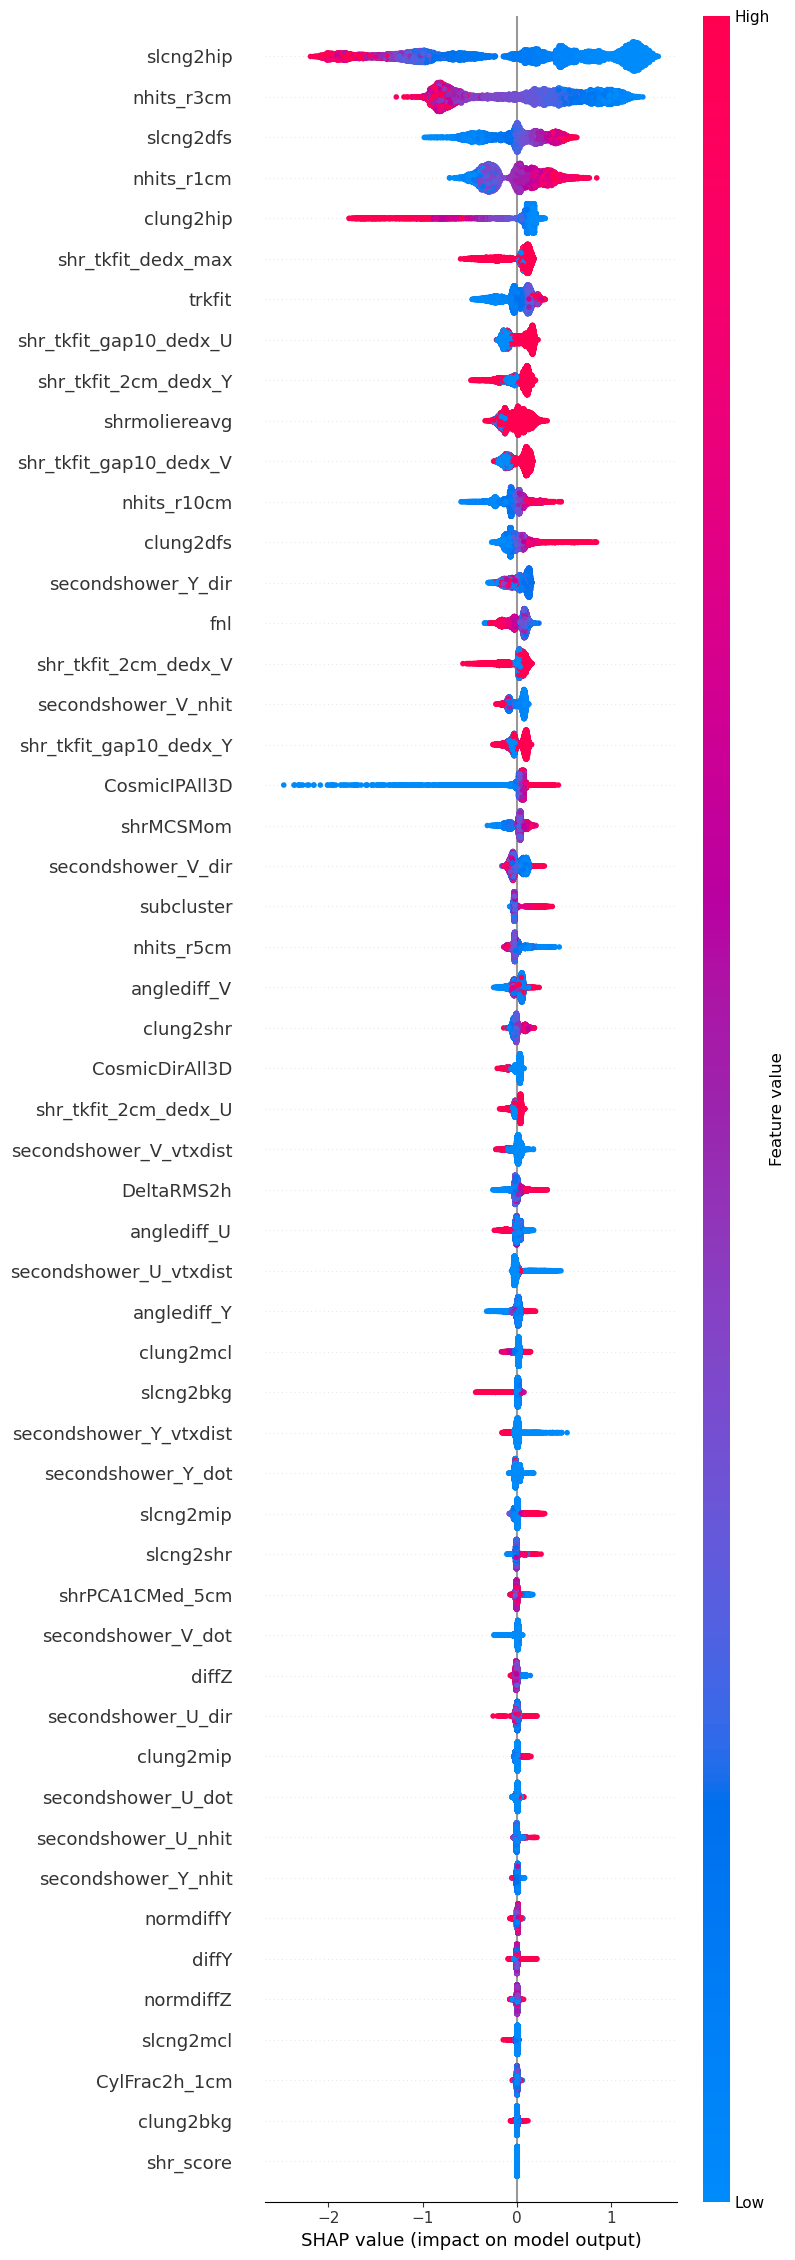

area under the precision-recall curve: 0.923406
precision score: 0.825208
recall score: 0.898817
Importance (total_gain):
slcng2hip 52986.47594413394
nhits_r3cm 11595.010351639983
clung2hip 6520.047231230006
slcng2dfs 5923.11462926
nhits_r1cm 4410.948072190004
shr_tkfit_dedx_max 4376.447200022999
CosmicIPAll3D 3601.571816495
clung2dfs 3411.752781675998
trkfit 2725.6066310110027
nhits_r5cm 2698.5601941399973
shr_tkfit_gap10_dedx_U 2633.133348919998
shr_tkfit_2cm_dedx_Y 2421.831619599
nhits_r10cm 2314.6523635099993
shr_tkfit_gap10_dedx_V 2047.9051164
shr_tkfit_gap10_dedx_Y 1857.30111551
shr_tkfit_2cm_dedx_V 1776.5822951100008
secondshower_Y_dir 1711.0162234099994
shrMCSMom 1509.337401195999
fnl 1492.175901135
shrmoliereavg 1405.9102467009996
secondshower_V_dir 1286.3052449229995
anglediff_Y 1161.2227651199996
anglediff_V 1108.6219363240002
secondshower_Y_vtxdist 1070.5449020620003
clung2shr 1066.0658110500003
secondshower_V_vtxdist 1043.14225348
DeltaRMS2h 1008.1905909708303
shr_tkfit_2c

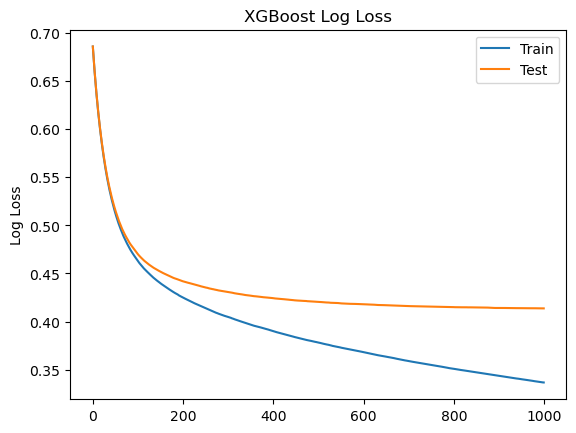

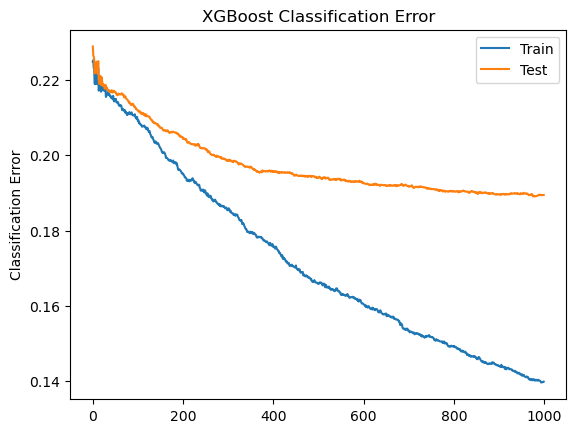

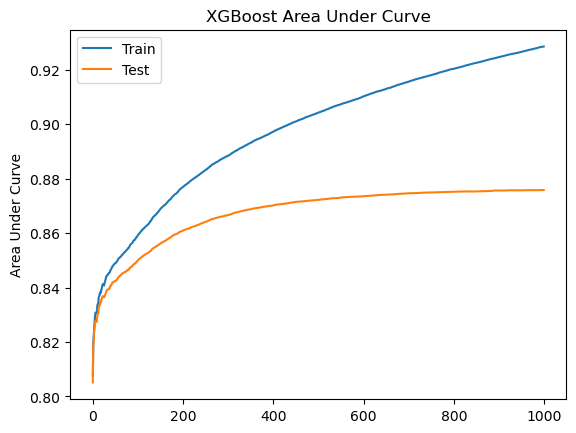

In [22]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster_stacked_numi)
my_booster = nue_booster_stacked_numi.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and shrmoliereavg < 20'
# PRESEL += ' and subcluster > 5'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
# PRESEL += ' and shr_trk_len > 20'
# PRESEL += ' and CylFrac2h_1cm < 0.7'
# PRESEL += ' and shrMCSMom > 20'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

# PRESEL += ' and diffZ > -70 and diffZ < 80'
# PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
# PRESEL += ' and fnl > -200 and fnl < 50'

PRESEL += ' and nonpi0_score > 0.4'
PRESEL += ' and pi0_score > 0.25'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster_stacked_numi.labels, nue_booster_stacked_numi.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_numi_4cd5FHC_zppresel_stacked_75.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [27]:
if second_split_type == 'simple':
    print('mc',train_nu_25p.query(PRESEL)["train_weight"].sum())
    print('nue',train_nue_25p.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt_25p.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0_25p.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext_25p.query(PRESEL)["train_weight"].sum())

if second_split_type == 'nuequery':
    print('mc',train_nu_25p.query(PRESEL)["train_weight"].sum())
    print('nue_signal',train_nue_signal.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',train_nue_bkg.query(PRESEL)["train_weight"].sum())
    print('dirt',train_dirt_25p.query(PRESEL)["train_weight"].sum())
    print('ncpi0',train_ncpi0_25p.query(PRESEL)["train_weight"].sum())
    print('ext',train_ext_25p.query(PRESEL)["train_weight"].sum())

mc 247.0
nue_signal 6508.0
nue_bkg 6042.0
dirt 8.0
ncpi0 1373.0
ext 970.0


In [28]:
if second_split_type == 'simple':
    print('mc',test_nu_25p.query(PRESEL)["train_weight"].sum())
    print('nue',test_nue_25p.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt_25p.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0_25p.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext_25p.query(PRESEL)["train_weight"].sum())

if second_split_type == 'nuequery':
    print('mc',test_nu_25p.query(PRESEL)["train_weight"].sum())
    print('nue_signal',test_nue_signal.query(PRESEL)["train_weight"].sum())
    print('nue_bkg',test_nue_bkg.query(PRESEL)["train_weight"].sum())
    print('dirt',test_dirt_25p.query(PRESEL)["train_weight"].sum())
    print('ncpi0',test_ncpi0_25p.query(PRESEL)["train_weight"].sum())
    print('ext',test_ext_25p.query(PRESEL)["train_weight"].sum())

mc 748.0
nue_signal 19529.0
nue_bkg 17925.0
dirt 23.0
ncpi0 4237.0
ext 3200.0


{'slcng2hip': 52986.47594413394, 'nhits_r3cm': 11595.010351639983, 'shr_tkfit_dedx_max': 4376.447200022999, 'clung2hip': 6520.047231230006, 'nhits_r5cm': 2698.5601941399973, 'nhits_r10cm': 2314.6523635099993, 'CosmicIPAll3D': 3601.571816495, 'slcng2dfs': 5923.11462926, 'clung2dfs': 3411.752781675998, 'trkfit': 2725.6066310110027, 'nhits_r1cm': 4410.948072190004, 'subcluster': 893.36607342, 'shr_tkfit_2cm_dedx_Y': 2421.831619599, 'shrmoliereavg': 1405.9102467009996, 'CylFrac2h_1cm': 363.48354931000006, 'clung2mip': 243.93374774800003, 'slcng2shr': 766.3248705739999, 'shrMCSMom': 1509.337401195999, 'DeltaRMS2h': 1008.1905909708303, 'shr_tkfit_2cm_dedx_U': 970.2545780900001, 'secondshower_U_dir': 793.4333584130004, 'secondshower_Y_dir': 1711.0162234099994, 'clung2shr': 1066.0658110500003, 'fnl': 1492.175901135, 'secondshower_U_nhit': 479.845611156, 'normdiffZ': 353.98937846699994, 'secondshower_V_vtxdist': 1043.14225348, 'secondshower_V_dir': 1286.3052449229995, 'anglediff_U': 917.0097608

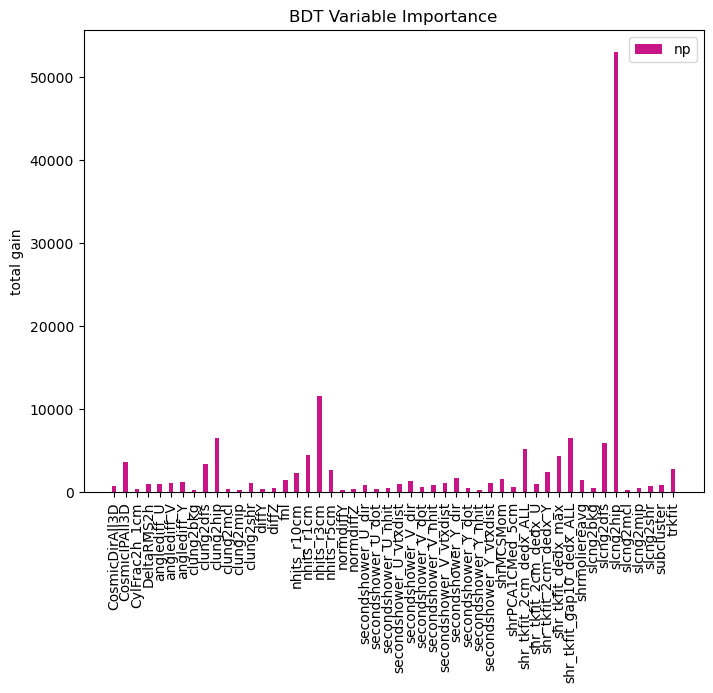

In [29]:
print(gain_imp['np'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['np']['shr_tkfit_gap10_dedx_V']+gain_imp['np']['shr_tkfit_gap10_dedx_U']+gain_imp['np']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['np']['shr_tkfit_gap10_dedx_V']
    del gain_imp['np']['shr_tkfit_gap10_dedx_U']
    del gain_imp['np']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['np']['shr_tkfit_2cm_dedx_V']+gain_imp['np']['shr_tkfit_2cm_dedx_U']+gain_imp['np']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['np']['shr_tkfit_2cm_dedx_V']

print(gain_imp['np'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
np_imp = []

for i in sorted (gain_imp['np'].keys()) :  
    labels.append(i)
    np_imp.append(gain_imp['np'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects2 = ax.bar(x, np_imp, width, label='np', color='mediumvioletred')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

{'slcng2hip': 50, 'nhits_r3cm': 49, 'shr_tkfit_gap10_dedx_ALL': 48, 'clung2hip': 47, 'slcng2dfs': 46, 'shr_tkfit_2cm_dedx_ALL': 45, 'nhits_r1cm': 44, 'shr_tkfit_dedx_max': 43, 'CosmicIPAll3D': 42, 'clung2dfs': 41, 'trkfit': 40, 'nhits_r5cm': 39, 'shr_tkfit_2cm_dedx_Y': 38, 'nhits_r10cm': 37, 'secondshower_Y_dir': 36, 'shrMCSMom': 35, 'fnl': 34, 'shrmoliereavg': 33, 'secondshower_V_dir': 32, 'anglediff_Y': 31, 'anglediff_V': 30, 'secondshower_Y_vtxdist': 29, 'clung2shr': 28, 'secondshower_V_vtxdist': 27, 'DeltaRMS2h': 26, 'shr_tkfit_2cm_dedx_U': 25, 'anglediff_U': 24, 'secondshower_U_vtxdist': 23, 'subcluster': 22, 'secondshower_V_nhit': 21, 'secondshower_U_dir': 20, 'slcng2shr': 19, 'CosmicDirAll3D': 18, 'shrPCA1CMed_5cm': 17, 'secondshower_V_dot': 16, 'slcng2bkg': 15, 'secondshower_Y_dot': 14, 'secondshower_U_nhit': 13, 'diffZ': 12, 'slcng2mip': 11, 'clung2mcl': 10, 'diffY': 9, 'CylFrac2h_1cm': 8, 'normdiffZ': 7, 'secondshower_U_dot': 6, 'normdiffY': 5, 'clung2mip': 4, 'secondshower_Y

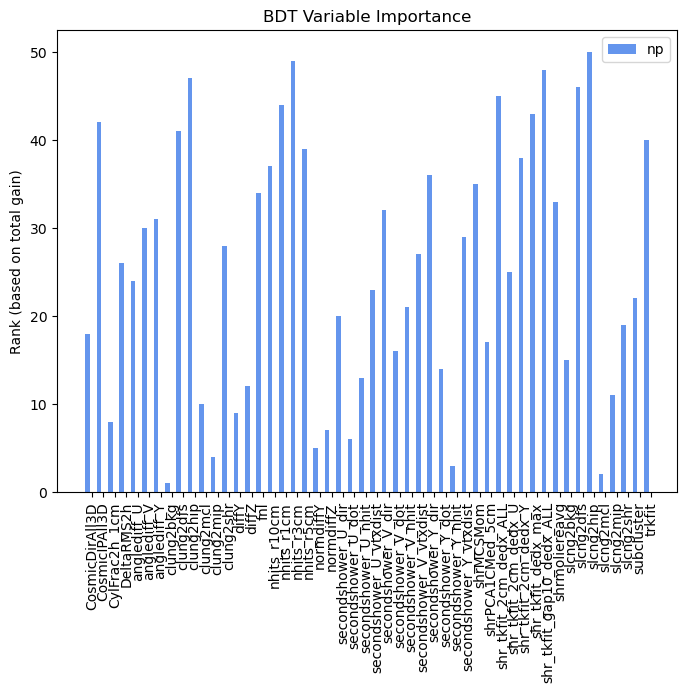

In [26]:
d_np_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['np'], key=gain_imp['np'].get, reverse=True):
    d_np_rnk[w] = rnk
    rnk = rnk-1
print(d_np_rnk)

np_rnk = []

for i in labels:  
    np_rnk.append(d_np_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, np_rnk, width, label='np', color='cornflowerblue')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")